# Кошка или собака: ResNet18
Подготовка данных, обучение, метрики и вероятности для нового фото. Выполняй ячейки сверху вниз.

В этом запуске использована ResNet18 с изменёнными начальными слоями. Сохранённая test accuracy — 88,87%. Это результат исходного запуска; при редактировании пояснений обучение не повторялось.

### 1. Библиотеки и настройки
Подключаем библиотеки, задаём seed, пути и устройство CUDA/MPS/CPU. Первые две строки обновляют PyTorch и torchvision. `N_IMAGES` ограничивает число фото. Сейчас число эпох задаётся непосредственно в шаге 9, поэтому `EPOCHS = 5` не используется.

In [1]:
!pip install torch --upgrade -q
!pip install torchvision --upgrade -q

import os
import csv
import random
import shutil
import tempfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torchvision import transforms
from torch import nn, optim
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

SRC_DIR = os.path.expanduser("~/Downloads/train")
MODEL_PATH = "cat_dog_fixed.pt"
N_IMAGES = 10000
EPOCHS = 5

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Устройство:", device)

Устройство: mps


### 2. Обработка фотографий
Уменьшаем изображение до 32×32, с вероятностью 50% отражаем слева направо, создаём тензор и нормализуем пиксели.

**Особенность текущего кода:** этот общий `transform` применяется также к validation, test и новым фото. Поэтому результаты могут меняться при повторной проверке. Для постоянной оценки нужно оставить случайное отражение только в обработке train.

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3. Разделение данных
Берём до 10 000 файлов с именами `cat.*` и `dog.*`. Для каждого класса выделяем 20% в test. Копии сохраняем в новую папку `dataset_resnet_*`, исходники не изменяем.
В записанном запуске найдено 9972 фото. Для ровно 10 000 нужны ещё 28.

In [3]:
random.seed(SEED)
files = [
    name for name in sorted(os.listdir(SRC_DIR))
    if name.lower().endswith((".jpg", ".jpeg", ".png"))
    and name.lower().startswith(("cat.", "dog."))
    and os.path.isfile(os.path.join(SRC_DIR, name))
]
random.shuffle(files)
files = files[:N_IMAGES]

by_class = {"cat": [], "dog": []}
for name in files:
    label = name.split(".")[0].lower()
    by_class[label].append(name)

if min(len(by_class["cat"]), len(by_class["dog"])) < 10:
    raise ValueError("Нужно хотя бы 10 фотографий каждого класса. Проверь SRC_DIR.")

DST_DIR = tempfile.mkdtemp(prefix="dataset_resnet_", dir=".")
for label, items in by_class.items():
    random.shuffle(items)
    n_test = int(len(items) * 0.2)

    for split, names in [("test", items[:n_test]), ("train", items[n_test:])]:
        dst_folder = os.path.join(DST_DIR, split, label)
        os.makedirs(dst_folder)
        for name in names:
            shutil.copy(os.path.join(SRC_DIR, name), os.path.join(dst_folder, name))

print("Папка выборки:", DST_DIR)
print("Всего фото:", len(files))
if len(files) < N_IMAGES:
    print("До нужного количества не хватает:", N_IMAGES - len(files))

Папка выборки: /Users/artem/Desktop/cat-dog-resnet18 2/dataset_resnet_lxq2u2id
Всего фото: 9972
До нужного количества не хватает: 28


### 4. Создание меток
`ImageFolder` читает фотографии из папок. Метка кошки — 0, собаки — 1. Проверяем одинаковое соответствие классов для train и test.

In [4]:
train_data = torchvision.datasets.ImageFolder(
    root=os.path.join(DST_DIR, "train"), transform=transform
)
test_data = torchvision.datasets.ImageFolder(
    root=os.path.join(DST_DIR, "test"), transform=transform
)

assert train_data.class_to_idx == test_data.class_to_idx == {"cat": 0, "dog": 1}
print("Метки:", train_data.class_to_idx)

Метки: {'cat': 0, 'dog': 1}


### 5. Validation и батчи
Из train выделяем 12,5% каждого класса в validation. Получаем примерно 70/10/20% всего набора. `DataLoader` собирает тензоры формы `(batch_size, 3, 32, 32)`.
Последний неполный батч train пропускается; validation и test проверяются полностью.

In [5]:
train_indices = []
val_indices = []

for label in [0, 1]:
    indices = [
        i for i, target in enumerate(train_data.targets)
        if target == label
    ]

    random.shuffle(indices)

    # 12.5% от исходных 80% — примерно 10% всего набора.
    n_val = max(1, int(len(indices) * 0.125))

    val_indices.extend(indices[:n_val])
    train_indices.extend(indices[n_val:])

train_subset = Subset(train_data, train_indices)
val_subset = Subset(train_data, val_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

print("Train:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_data))

images, labels = next(iter(train_loader))
print("Тензор фотографий:", images.shape)
print("Тензор меток:", labels.shape)

Train: 6981
Validation: 997
Test: 1994
Тензор фотографий: torch.Size([32, 3, 32, 32])
Тензор меток: torch.Size([32])


### 6. Создание модели
Берём предобученную ResNet18. Меняем шаг первой свёртки на 1 и убираем начальный MaxPool, чтобы меньше уменьшать изображения 32×32. Последний слой выдаёт два числа.
`CrossEntropyLoss` измеряет ошибку. Adam обновляет веса с `lr=0.0001` и `weight_decay=0.0001`. Dropout в этой версии нет.

In [6]:
def create_model(pretrained=True):
    weights = (
        torchvision.models.ResNet18_Weights.DEFAULT
        if pretrained else None
    )

    model = torchvision.models.resnet18(weights=weights)
    model.conv1.stride = (1, 1)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 2)

    return model

model = create_model().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

### 7. Функция train_epoch
Одна эпоха — проход по обучающим батчам. Получаем ответы, считаем ошибку, вычисляем градиенты и обновляем веса. Возвращаем среднюю ошибку и долю правильных ответов.

In [7]:
def train_epoch(model, optimizer, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += len(labels)

    return total_loss / total, correct / total

### 8. Функция test
Проверяем модель без обновления весов и расчёта градиентов. Возвращаем loss, accuracy и матрицу ошибок. Строки матрицы — правильные классы, столбцы — ответы модели.

In [8]:
def test(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0
    matrix = torch.zeros(2, 2, dtype=torch.int64)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * len(labels)
            correct += (predictions == labels).sum().item()
            total += len(labels)

            for actual, predicted in zip(
                labels.cpu().tolist(),
                predictions.cpu().tolist()
            ):
                matrix[actual, predicted] += 1

    return total_loss / total, correct / total, matrix

### 9. Обучение и сохранение
Запускаем 6 эпох — это число указано прямо в вызове `train`. Записываем метрики и сохраняем веса при уменьшении validation loss.
В записанном запуске лучшие веса выбраны на 3-й эпохе (`val loss=0.3344`). При новом запуске функции история и лучший loss начинаются заново; файл весов может быть перезаписан.

In [9]:
def train(model, optimizer, n_epochs, train_loader, val_loader):
    train_loss_log = []
    val_loss_log = []
    train_acc_log = []
    val_acc_log = []

    best_loss = float("inf")

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(
            model, optimizer, train_loader
        )

        val_loss, val_acc, _ = test(model, val_loader)

        train_loss_log.append(train_loss)
        val_loss_log.append(val_loss)
        train_acc_log.append(train_acc)
        val_acc_log.append(val_acc)

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), MODEL_PATH)

        print(
            f"Эпоха {epoch + 1}: "
            f"train loss={train_loss:.4f}, accuracy={train_acc:.2%} | "
            f"val loss={val_loss:.4f}, accuracy={val_acc:.2%}"
        )

    return train_loss_log, val_loss_log, train_acc_log, val_acc_log



train_loss_log, val_loss_log, train_acc_log, val_acc_log = train(
    model, optimizer, 6, train_loader, val_loader
)

Эпоха 1: train loss=0.4026, accuracy=81.98% | val loss=0.3787, accuracy=82.95%
Эпоха 2: train loss=0.2099, accuracy=91.76% | val loss=0.3628, accuracy=85.36%
Эпоха 3: train loss=0.1411, accuracy=94.44% | val loss=0.3344, accuracy=87.06%
Эпоха 4: train loss=0.0937, accuracy=96.79% | val loss=0.4541, accuracy=84.55%
Эпоха 5: train loss=0.0697, accuracy=97.38% | val loss=0.3422, accuracy=87.86%
Эпоха 6: train loss=0.0711, accuracy=97.31% | val loss=0.3599, accuracy=88.16%


### 10. Графики обучения
`plot_history` показывает ошибку и точность train и validation по эпохам. Рост train при ухудшении validation может указывать на переобучение.

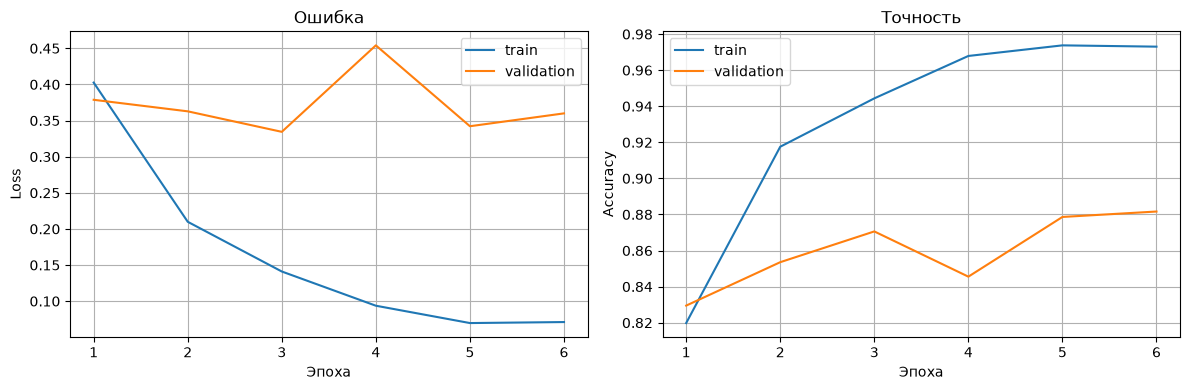

In [12]:
def plot_history(train_loss_log, val_loss_log,
                 train_acc_log, val_acc_log):

    epochs = range(1, len(train_loss_log) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_log, label="train")
    plt.plot(epochs, val_loss_log, label="validation")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("Ошибка")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_log, label="train")
    plt.plot(epochs, val_acc_log, label="validation")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title("Точность")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


plot_history(
    train_loss_log, val_loss_log,
    train_acc_log, val_acc_log
)

### 11. Итоговая проверка
Загружаем лучшие веса в обучающую архитектуру и считаем метрики на test. Accuracy — доля правильных ответов, precision — точность ответов класса, recall — доля найденных представителей класса, F1 объединяет precision и recall.
Сохранённый результат: accuracy 88,87%, F1 кошки 0,885 и собаки 0,892. Проверка использует случайное отражение из шага 2, поэтому повторная оценка может отличаться.

In [13]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

test_loss, test_accuracy, matrix = test(model, test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

print("\nМатрица ошибок:")
print("Строки — правильный класс, столбцы — предсказанный")
print("Порядок классов: cat, dog")
print(matrix.numpy())

print("\nМетрики по классам:")

for i, name in enumerate(train_data.classes):
    correct_class = matrix[i, i].item()
    predicted_class = matrix[:, i].sum().item()
    actual_class = matrix[i, :].sum().item()

    precision = (
        correct_class / predicted_class if predicted_class > 0 else 0
    )

    recall = (
        correct_class / actual_class if actual_class > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )

    print(
        f"{name}: precision={precision:.3f}, "
        f"recall={recall:.3f}, F1={f1:.3f}"
    )

Test loss: 0.3087
Test accuracy: 88.72%

Матрица ошибок:
Строки — правильный класс, столбцы — предсказанный
Порядок классов: cat, dog
[[855 137]
 [ 88 914]]

Метрики по классам:
cat: precision=0.907, recall=0.862, F1=0.884
dog: precision=0.870, recall=0.912, F1=0.890


### 12. Загрузка весов для предсказания
Создаём отдельную ResNet18 и загружаем веса из `MODEL_PATH`.

**Нужно учесть:** в этой ячейке не повторены изменения начальных слоёв из шага 6. Чтобы расчёт совпадал с обучением, после создания `saved_model` нужно установить `saved_model.conv1.stride = (1, 1)` и `saved_model.maxpool = nn.Identity()`. Загрузка весов сама эти настройки не восстанавливает. В этой редакции изменены только пояснения; код ниже сохранён как в исходнике.

In [14]:
saved_model = torchvision.models.resnet18(weights=None)
saved_model.conv1.stride = (1, 1)
saved_model.maxpool = nn.Identity()
saved_model.fc = nn.Linear(saved_model.fc.in_features, 2)
saved_model = saved_model.to(device)

saved_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)
saved_model.eval()

class_names = ["cat", "dog"]
print("Сохранённая ResNet18 загружена.")

Сохранённая ResNet18 загружена.


### 13. Функция predict
Открываем RGB-фотографию и передаём её в `saved_model`. `softmax` преобразует два выхода в вероятности кошки и собаки. Показываем оба процента и изображение.
Имя файла не влияет на класс. Перед использованием учти замечания к обработке и архитектуре в шагах 2 и 12.

In [15]:
def predict(path):
    with Image.open(os.path.expanduser(path)) as image:
        photo = image.convert("RGB")

    tensor = transform(photo).unsqueeze(0).to(device)

    saved_model.eval()
    with torch.no_grad():
        outputs = saved_model(tensor)
        probabilities = torch.softmax(outputs, dim=1)[0].cpu()

    result = {
        "cat": probabilities[0].item(),
        "dog": probabilities[1].item()
    }

    print(f"Кошка: {result['cat']:.2%}")
    print(f"Собака: {result['dog']:.2%}")

    plt.figure(figsize=(4, 4))
    plt.imshow(photo)
    plt.title(f"Кошка: {result['cat']:.2%} | Собака: {result['dog']:.2%}")
    plt.axis("off")
    plt.show()

    return result

### 14. Примеры из test
Показываем по две фотографии каждого класса, правильную метку и ответ загруженной модели. Четыре примера не заменяют оценку на всём test.

Правильный класс: cat
Кошка: 99.97%
Собака: 0.03%


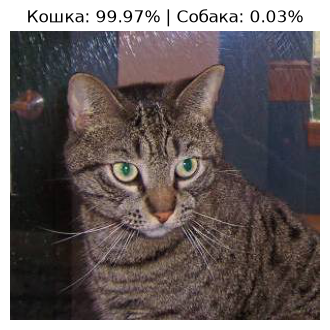

Ответ модели: cat
Верно

Правильный класс: cat
Кошка: 99.50%
Собака: 0.50%


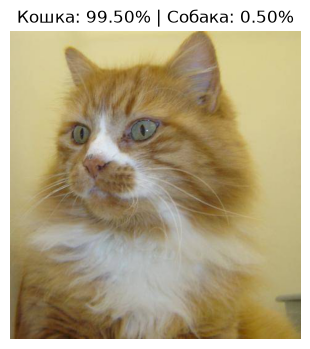

Ответ модели: cat
Верно

Правильный класс: dog
Кошка: 0.00%
Собака: 100.00%


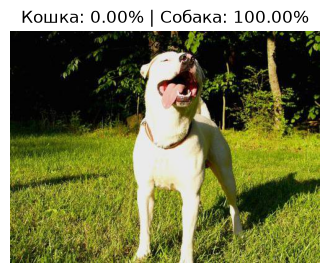

Ответ модели: dog
Верно

Правильный класс: dog
Кошка: 0.13%
Собака: 99.87%


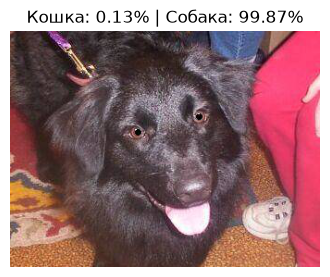

Ответ модели: dog
Верно



In [16]:
for label in [0, 1]:
    paths = [path for path, target in test_data.samples if target == label][:2]
    for path in paths:
        print("Правильный класс:", class_names[label])
        result = predict(path)
        predicted = max(result, key=result.get)
        print("Ответ модели:", predicted)
        print("Верно" if predicted == class_names[label] else "Ошибка")
        print()

### 15. Своя фотография
Укажи путь в `photo_path`. Получаем проценты и выбираем класс с большей вероятностью. Для независимой проверки используй фото, которого не было в обучении.
Проценты — оценки модели, а не гарантия. Сеть выбирает только между кошкой и собакой.

Кошка: 2.84%
Собака: 97.16%


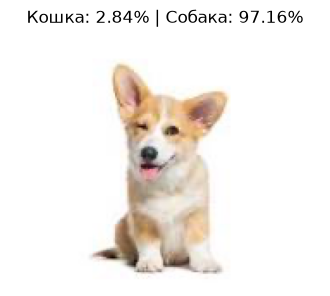

Итог: собака — 97.16%


In [17]:
photo_path = "~/Downloads/photo.jpeg"  # Например: "~/Downloads/photo_001.jpg"

if photo_path:
    result = predict(photo_path)

    if result["cat"] >= result["dog"]:
        print(f"Итог: кошка — {result['cat']:.2%}")
    else:
        print(f"Итог: собака — {result['dog']:.2%}")
else:
    print("Укажи путь в photo_path и запусти эту ячейку.")

### 16. Экспорт фотографий в CSV
Записываем все выбранные фотографии: train, validation и test. Одна строка — метка и 3072 RGB-значения от 0 до 255. Пиксели идут строка за строкой, каналы R, G, B. Нормализация и случайное отражение при экспорте не применяются.
CSV содержит данные; обученные веса хранятся отдельно в `.pt`.

In [18]:
csv_transform = transforms.Resize((32, 32))

with open("cat_dog_fixed.csv", "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow(
        ["label"] + [f"pixel_{i}" for i in range(3072)]
    )

    for path, label in train_data.samples + test_data.samples:
        with Image.open(path) as image:
            image = csv_transform(image.convert("RGB"))
            pixels = np.array(image).reshape(-1)

        writer.writerow([label] + pixels.tolist())

print("CSV сохранён.")
print("Количество фото:", len(train_data) + len(test_data))

CSV сохранён.
Количество фото: 9972


### 17. Версии библиотек
Записываем установленные версии пяти библиотек в `requirements.txt`. Файл в рабочей папке будет перезаписан.


In [19]:
from importlib.metadata import version

libraries = ["torch", "torchvision", "numpy", "matplotlib", "Pillow"]

with open("requirements.txt", "w") as file:
    for library in libraries:
        file.write(f"{library}=={version(library)}\n")

print("requirements.txt сохранён")

requirements.txt сохранён
